# Unit 2: Numerical Integration

Welcome to Unit 2! In Unit 1, we asked the question: *"How fast is this function changing at an exact moment?"* We answered this by finding the slope of the tangent line, known as the **derivative**.

Now, we are going to ask a completely different question: *"How much of something has accumulated over time?"* Graphically, this is equivalent to finding the **total area under the curve**. This process is called **integration**.

Let's load our tools and see how we can calculate area using Python.


In [1]:
import numpy as np
import matplotlib.pyplot as plt



## 1. The Concept of Riemann Sums

If I ask you to find the area of a rectangle, it is easy: $Area = width \times height$.
But how do you find the area under a curve like $f(x) = x^2$? The height is constantly changing!

A mathematician named Bernhard Riemann came up with a clever numerical solution: cut the area into a bunch of rectangles. We calculate the area of each rectangle, and then sum them all up. This is called a **Riemann Sum**.

The width of each rectangle is a small step size, which we will call $dx$ (or $\Delta x$). The height is the function evaluated at that specific $x$, which is $f(x)$.


In [2]:

# The function we want to find the area under
def f(x):
    return x**2

# The interval we care about (from a to b)
a = 0.0
b = 3.0

# The number of rectangles we want to draw
n = 5

# The width of each rectangle (total distance divided by number of rectangles)
dx = (b - a) / n

print(f"We are using {n} rectangles, each with a width of dx = {dx}")


We are using 5 rectangles, each with a width of dx = 0.6


## 2. Left, Right, and Midpoint Sums

When we place our rectangles under the curve, where exactly should the top of the rectangle touch the curve? We have three main choices:

1. **Left Riemann Sum:** The top-left corner of the rectangle touches the curve.
2. **Right Riemann Sum:** The top-right corner of the rectangle touches the curve.
3. **Midpoint Riemann Sum:** The exact middle of the rectangle's top touches the curve.

Let's write code to calculate the area using a **Left Riemann Sum**.


In [3]:
# Generate the left x-coordinates for our 5 rectangles
# np.linspace creates evenly spaced numbers, but we leave off the very last point 
# because it would represent the start of a 6th rectangle!
x_left = np.linspace(a, b, n, endpoint=False)
print("Left x-coordinates:", x_left)

# Calculate the heights at these x-coordinates
heights = f(x_left)

# Area = sum of (height * width)
left_area = np.sum(heights * dx)
print("Left Riemann Sum Area:", left_area)


Left x-coordinates: [0.  0.6 1.2 1.8 2.4]
Left Riemann Sum Area: 6.4799999999999995


## 3. Visualizing the Rectangles

Numbers are great, but seeing the rectangles makes it click. We can use `plt.bar` to physically draw the Riemann Sum we just calculated.


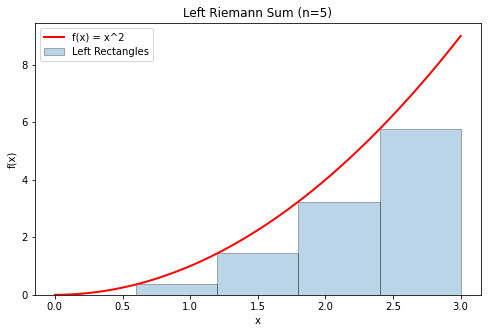

In [4]:
# Create a smooth curve for the actual function
x_smooth = np.linspace(a, b, 100)
y_smooth = f(x_smooth)

plt.figure(figsize=(8, 5))

# Plot the smooth curve
plt.plot(x_smooth, y_smooth, 'r-', linewidth=2, label="f(x) = x^2")

# Plot the rectangles!
# align='edge' makes the bar start exactly at our x_left coordinate
plt.bar(x_left, heights, width=dx, alpha=0.3, align='edge', edgecolor='black', label="Left Rectangles")

plt.title("Left Riemann Sum (n=5)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

Notice all the empty white space between the rectangles and the red curve? Because $f(x) = x^2$ is increasing, the Left Riemann Sum **underestimates** the true area.

## Challenge 1: The Right Riemann Sum

**Your Task:**

1. Copy the code block where we calculated the Left Riemann sum.
2. Modify it to calculate the **Right Riemann Sum**.
3. *Hint:* To get the right-side coordinates, you don't want to start at $a = 0$. You want to start one $dx$ step forward, and end exactly at $b = 3$. You can create this array by adding $dx$ to your `x_left` array!
4. Print the result. (Since the curve goes up, this should overestimate the area).


In [5]:
# Write your code to calculate the Right Riemann Sum here!


## Challenge 2: The Midpoint Riemann Sum

The midpoint sum is usually much more accurate than the left or right sums because the errors on either side of the midpoint tend to cancel each other out.

**Your Task:**

1. Calculate the $x$-coordinates for the middle of each rectangle.
2. *Hint:* The first midpoint is located at $a + (dx / 2)$.
3. Calculate the heights at these midpoints and sum up the total area.
4. Print the Midpoint Area.


In [6]:
# Write your code to calculate the Midpoint Riemann Sum here!


## 4. Increasing Accuracy & The Trapezoidal Rule

If 5 rectangles give us a clunky approximation, how do we get a better answer? We use *more rectangles*. Let's wrap our logic into a reusable function and test it with 10,000 rectangles.

We will also introduce the **Trapezoidal Rule**. Instead of a flat-topped rectangle, this rule connects the left and right heights with a slanted line, creating a trapezoid.
The area of one trapezoid is: $\frac{f(x_{left}) + f(x_{right})}{2} \cdot dx$


In [7]:
def trapezoidal_rule(f, a, b, n):
    """
    Calculates the integral of f(x) from a to b using n trapezoids.
    """
    dx = (b - a) / n
    
    # Get all the x coordinates, including both the very first and very last point
    x_edges = np.linspace(a, b, n + 1)
    y_edges = f(x_edges)
    
    # Calculate the left heights and right heights for each trapezoid
    left_heights = y_edges[:-1]
    right_heights = y_edges[1:]
    
    # Apply the trapezoid area formula and sum them up
    areas = ((left_heights + right_heights) / 2) * dx
    return np.sum(areas)

# Let's test it with a massive number of shapes!
true_area = 9.0  # (The exact mathematical area under x^2 from 0 to 3)

trap_area = trapezoidal_rule(f, 0.0, 3.0, 10000)
print(f"Area using 10,000 trapezoids: {trap_area}")
print(f"Absolute Error: {np.abs(true_area - trap_area)}")


Area using 10,000 trapezoids: 9.000000044999997
Absolute Error: 4.499999661788934e-08
